# Used Car Price Analysis (CRISP-DM)


## 1. Business Understanding
Objectives: Identify what factors most strongly influence used car prices and provide recommendations to car dealerships.
Plan: Understand data, prepare the data, explore the data, use modeling, evaluate the findings, provide recommendations to the car dealership

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/vehicles.csv')
df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: '/data/vehicles.csv'

## 2. Data Understanding
Preview data columns and type.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [4]:
df['price'].describe()

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64

## 3. Data Preparation
Preparting the dataset to only keep rows with Price>0 or empty.
Convert the price and odometer to Log as the price range and odometer range is abnormally high based on .describe()
Calculate Age from 2025 to analyze the impact of Age of the car.

In [13]:
# Clean price
df = df[df['price'].notnull() & (df['price'] > 0)]
df = df[df['odometer'].notnull() & (df['odometer'] > 0)]

# Feature engineering
df['age'] = 2025 - df['year']
df['log_price'] = np.log(df['price'])
df['log_odometer'] = np.log(df['odometer'])
df[['age','odometer','log_price', 'log_odometer']].head()

,age,odometer,log_price,log_odometer
27,11.0,57923.0,10.421984,10.966870
28,15.0,71229.0,10.025263,11.173655
29,5.0,19160.0,10.586332,9.860580
30,8.0,41124.0,10.341420,10.624347
31,12.0,128000.0,9.615805,11.759786


## 4. Exploratory Data Analysis

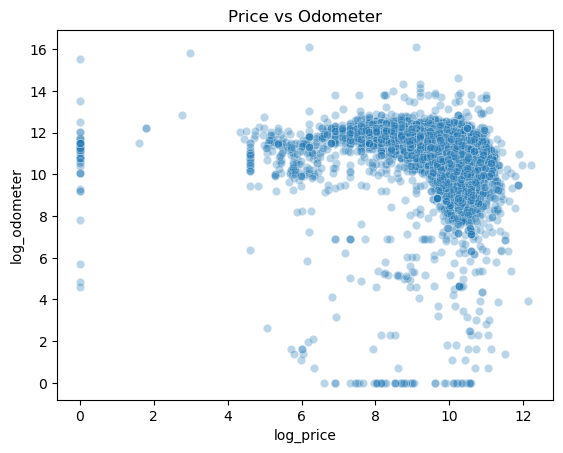

In [15]:
sns.scatterplot(data=df.sample(10000), x='log_price', y='log_odometer', alpha=0.3)
plt.title('Price vs Odometer')
plt.show()

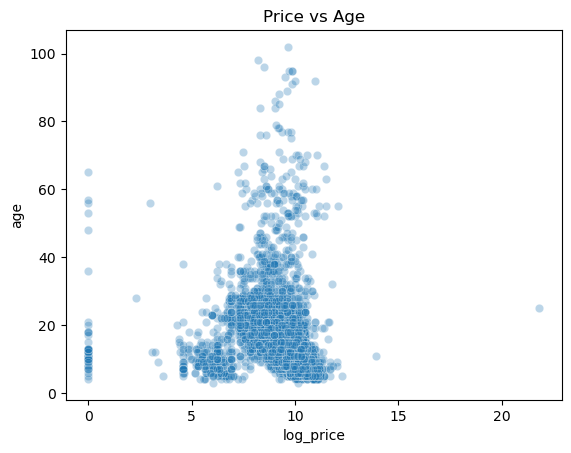

In [16]:
sns.scatterplot(data=df.sample(10000), x='log_price', y='age', alpha=0.3)
plt.title('Price vs Age')
plt.show()

### Correlation

In [19]:
df[['age','log_odometer','log_price']].corr()

,age,log_odometer,log_price
age,1.000000,0.156048,-0.273832
log_odometer,0.156048,1.000000,-0.195063
log_price,-0.273832,-0.195063,1.000000


## 5. Modeling (Linear Regression)
Perform Linear Regression on age and odometer.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['age','log_odometer']].fillna(df[['age','log_odometer']].median())
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
r2_score(y_test, pred)

0.09842900106278618

## 6. Evaluation of the observations
- Age- Strongly impact the price. Newer cars are sold at higher price.
- Odometer - Higher Mileage = Lower Price
- Opportunity to look into categorical variables to make the model even more effecient.


## 7. Deployment / Recommendation
- Look for Low-age and Low-Mileage Car in the inventory which should provide better price.
- There could be other categorical variables impact such as manufacturers or title status which may impact the price of the used car.